In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
iris = load_iris()
X = StandardScaler().fit_transform(iris.data)
X_train, X_test, y_train, y_test = train_test_split(X, iris.target, test_size=0.2)
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(4, 16)
        self.fc2 = nn.Linear(16, 3)
    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x)))

In [4]:
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
losses = []
for epoch in range(50):
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

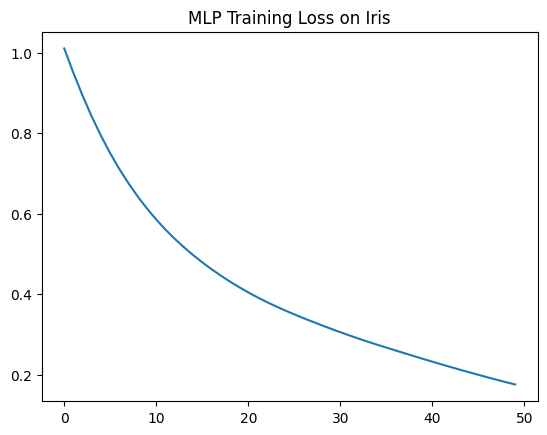

In [5]:
plt.plot(losses)
plt.title('MLP Training Loss on Iris')
plt.savefig('iris_mlp_loss.png')